##**Problem**
YouTube (the world-famous video sharing website) maintains a list of the top trending videos on the platform. According to Variety magazine, “To determine the year’s top-trending videos, YouTube uses a combination of factors including measuring users interactions (number of views, shares, comments and likes). Note that they’re not the most-viewed videos overall for the calendar year”. Top performers on the YouTube trending list are music videos (such as the famously virile “Gangam Style”), celebrity and/or reality TV performances, and the random dude-with-a-camera viral videos that YouTube is well-known for.

Possible uses for this dataset could include:

Sentiment analysis in a variety of forms                                                                          
Categorising YouTube videos based on their comments and statistics.

Training ML algorithms like RNNs to generate their own YouTube comments.

Analysing what factors affect how popular a YouTube video will be.
Statistical analysis over time

#**STATISTICAL ANALYSIS**

In [ ]:
import pandas as pd
import numpy as np

**Knowing The Data**

In [ ]:
df_in=pd.read_csv('/content/INvideos.csv')
df_in.sample(n=5)

,video_id,trending_date,title,channel_title,category_id,publish_time,tags,views,likes,dislikes,comment_count,thumbnail_link,comments_disabled,ratings_disabled,video_error_or_removed,description
21365,ZG1Su0QwPYs,18.13.03,Rangamma Mangamma Lyrical Video Song || Rangas...,T-Series Telugu,10,2018-03-08T12:30:07.000Z,"Rangamma Mangamma|""Rangamma Mangamma Song""|""Ra...",7905977,163773,8204,12296,https://i.ytimg.com/vi/ZG1Su0QwPYs/default.jpg,False,False,False,T-Series Telugu presents Rangamma Mangamma Vid...
16665,cDNJKtpP1ug,18.13.02,Why Sai Dharam Tej Always Follows Chiranjeevi'...,YOYO Cine Talkies,24,2018-02-11T07:40:47.000Z,"sai dharam tej|""ram charan""|""chiranjeevi""|""chi...",246676,0,0,0,https://i.ytimg.com/vi/cDNJKtpP1ug/default.jpg,True,True,False,Why Sai Dharam Tej Always Follows Chiranjeevi'...
9730,J6GbDoIqf0o,18.04.01,Balloon Movie Review | Dumbest Review | Anjali...,Smile Settai,23,2018-01-03T05:56:45.000Z,"Balloon|""Balloon review""|""Balloon movie review...",92375,2149,145,479,https://i.ytimg.com/vi/J6GbDoIqf0o/default.jpg,False,False,False,Balloon Movie Review - Enjoy the fun filled Re...
30203,Uib4LPVctD8,18.06.05,Bigg Boss Marathi Highlights 4th May | Usha Na...,Rajshri Marathi ShowBuz,24,2018-05-04T08:24:10.000Z,"Bigg Boss Marathi|""Latest Episode Of Bigg Boss...",149297,254,174,266,https://i.ytimg.com/vi/Uib4LPVctD8/default.jpg,False,False,False,Watch huge fight happening in the big boss hou...
10971,iU8Sporf96c,18.13.01,"vairamuthu andal issue, seeman challenge h raj...",Red Pix 24x7,1,2018-01-11T02:00:56.000Z,"h raja speech|""seeman latest""|""seeman speech l...",210541,1700,404,413,https://i.ytimg.com/vi/iU8Sporf96c/default.jpg,False,False,False,"vairamuthu andal issue, seeman challenge h raj..."


In [ ]:
df_in.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37352 entries, 0 to 37351
Data columns (total 16 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   video_id                37352 non-null  object
 1   trending_date           37352 non-null  object
 2   title                   37352 non-null  object
 3   channel_title           37352 non-null  object
 4   category_id             37352 non-null  int64 
 5   publish_time            37352 non-null  object
 6   tags                    37352 non-null  object
 7   views                   37352 non-null  int64 
 8   likes                   37352 non-null  int64 
 9   dislikes                37352 non-null  int64 
 10  comment_count           37352 non-null  int64 
 11  thumbnail_link          37352 non-null  object
 12  comments_disabled       37352 non-null  bool  
 13  ratings_disabled        37352 non-null  bool  
 14  video_error_or_removed  37352 non-null  bool  
 15  de

In [ ]:
df_in.describe()

,category_id,views,likes,dislikes,comment_count
count,37352.000000,3.735200e+04,3.735200e+04,3.735200e+04,37352.00000
mean,21.576596,1.060478e+06,2.708272e+04,1.665082e+03,2676.99743
std,6.556593,3.184932e+06,9.714510e+04,1.607617e+04,14868.31713
min,1.000000,4.024000e+03,0.000000e+00,0.000000e+00,0.00000
25%,23.000000,1.239155e+05,8.640000e+02,1.080000e+02,81.00000
50%,24.000000,3.045860e+05,3.069000e+03,3.260000e+02,329.00000
75%,24.000000,7.992912e+05,1.377425e+04,1.019250e+03,1285.00000
max,43.000000,1.254322e+08,2.912710e+06,1.545017e+06,827755.00000


In [ ]:
df_in.isnull().sum()

,0
video_id,0
trending_date,0
title,0
channel_title,0
category_id,0
publish_time,0
tags,0
views,0
likes,0
dislikes,0


In [ ]:
df_in['category_id'].describe()

,category_id
count,37352.000000
mean,21.576596
std,6.556593
min,1.000000
25%,23.000000
50%,24.000000
75%,24.000000
max,43.000000


In [ ]:
import json
with open('/content/IN_json_catgeory_id.json', 'r') as f:
    category_data = json.load(f)

In [ ]:
category_map = {}

for item in category_data['items']:
    category_map[int(item['id'])] = item['snippet']['title']
print(category_map)

{1: 'Film & Animation', 2: 'Autos & Vehicles', 10: 'Music', 15: 'Pets & Animals', 17: 'Sports', 18: 'Short Movies', 19: 'Travel & Events', 20: 'Gaming', 21: 'Videoblogging', 22: 'People & Blogs', 23: 'Comedy', 24: 'Entertainment', 25: 'News & Politics', 26: 'Howto & Style', 27: 'Education', 28: 'Science & Technology', 30: 'Movies', 31: 'Anime/Animation', 32: 'Action/Adventure', 33: 'Classics', 34: 'Comedy', 35: 'Documentary', 36: 'Drama', 37: 'Family', 38: 'Foreign', 39: 'Horror', 40: 'Sci-Fi/Fantasy', 41: 'Thriller', 42: 'Shorts', 43: 'Shows', 44: 'Trailers'}


In [ ]:
df_in['category_name'] = df_in['category_id'].map(category_map)

In [ ]:
df_in.head()

,video_id,trending_date,title,channel_title,category_id,publish_time,tags,views,likes,dislikes,comment_count,thumbnail_link,comments_disabled,ratings_disabled,video_error_or_removed,description,category_name
0,kzwfHumJyYc,17.14.11,Sharry Mann: Cute Munda ( Song Teaser) | Parmi...,Lokdhun Punjabi,1,2017-11-12T12:20:39.000Z,"sharry mann|""sharry mann new song""|""sharry man...",1096327,33966,798,882,https://i.ytimg.com/vi/kzwfHumJyYc/default.jpg,False,False,False,Presenting Sharry Mann latest Punjabi Song Cu...,Film & Animation
1,zUZ1z7FwLc8,17.14.11,"पीरियड्स के समय, पेट पर पति करता ऐसा, देखकर दं...",HJ NEWS,25,2017-11-13T05:43:56.000Z,"पीरियड्स के समय|""पेट पर पति करता ऐसा""|""देखकर द...",590101,735,904,0,https://i.ytimg.com/vi/zUZ1z7FwLc8/default.jpg,True,False,False,"पीरियड्स के समय, पेट पर पति करता ऐसा, देखकर दं...",News & Politics
2,10L1hZ9qa58,17.14.11,Stylish Star Allu Arjun @ ChaySam Wedding Rece...,TFPC,24,2017-11-12T15:48:08.000Z,Stylish Star Allu Arjun @ ChaySam Wedding Rece...,473988,2011,243,149,https://i.ytimg.com/vi/10L1hZ9qa58/default.jpg,False,False,False,Watch Stylish Star Allu Arjun @ ChaySam Weddin...,Entertainment
3,N1vE8iiEg64,17.14.11,Eruma Saani | Tamil vs English,Eruma Saani,23,2017-11-12T07:08:48.000Z,"Eruma Saani|""Tamil Comedy Videos""|""Films""|""Mov...",1242680,70353,1624,2684,https://i.ytimg.com/vi/N1vE8iiEg64/default.jpg,False,False,False,This video showcases the difference between pe...,Comedy
4,kJzGH0PVQHQ,17.14.11,why Samantha became EMOTIONAL @ Samantha naga ...,Filmylooks,24,2017-11-13T01:14:16.000Z,"Filmylooks|""latest news""|""telugu movies""|""telu...",464015,492,293,66,https://i.ytimg.com/vi/kJzGH0PVQHQ/default.jpg,False,False,False,why Samantha became EMOTIONAL @ Samantha naga ...,Entertainment


**DATA PROCESSING**

In [ ]:
df=df_in[['trending_date',
'publish_time',
'category_name',
'views',
'likes',
'dislikes',
'comment_count',
'comments_disabled',
'ratings_disabled']]

In [ ]:
df=df.dropna()

In [ ]:
df.head()

,trending_date,publish_time,category_name,views,likes,dislikes,comment_count,comments_disabled,ratings_disabled
0,17.14.11,2017-11-12T12:20:39.000Z,Film & Animation,1096327,33966,798,882,False,False
1,17.14.11,2017-11-13T05:43:56.000Z,News & Politics,590101,735,904,0,True,False
2,17.14.11,2017-11-12T15:48:08.000Z,Entertainment,473988,2011,243,149,False,False
3,17.14.11,2017-11-12T07:08:48.000Z,Comedy,1242680,70353,1624,2684,False,False
4,17.14.11,2017-11-13T01:14:16.000Z,Entertainment,464015,492,293,66,False,False


In [ ]:
df['comments_disabled']=df['comments_disabled'].astype(int)
df['ratings_disabled']=df['ratings_disabled'].astype(int)
df.head()

,trending_date,publish_time,category_name,views,likes,dislikes,comment_count,comments_disabled,ratings_disabled
0,17.14.11,2017-11-12T12:20:39.000Z,Film & Animation,1096327,33966,798,882,0,0
1,17.14.11,2017-11-13T05:43:56.000Z,News & Politics,590101,735,904,0,1,0
2,17.14.11,2017-11-12T15:48:08.000Z,Entertainment,473988,2011,243,149,0,0
3,17.14.11,2017-11-12T07:08:48.000Z,Comedy,1242680,70353,1624,2684,0,0
4,17.14.11,2017-11-13T01:14:16.000Z,Entertainment,464015,492,293,66,0,0


The column publish_time is an ISO datetime format so we will convert it to to proper datetime format and seperate into new differnt columns


In [ ]:
# Convert to datetime
df['publish_time'] = pd.to_datetime(df['publish_time'])

# Separate date and time
df['publish_date'] = df['publish_time'].dt.date
df['publish_clock_time'] = df['publish_time'].dt.time

# Time-series useful features
df['publish_hour'] = df['publish_time'].dt.hour
df['publish_weekday'] = df['publish_time'].dt.day_name()
df['publish_month'] = df['publish_time'].dt.month_name()
df['publish_year'] = df['publish_time'].dt.year

In [ ]:
df.head()

,trending_date,publish_time,category_name,views,likes,dislikes,comment_count,comments_disabled,ratings_disabled,publish_date,publish_clock_time,publish_hour,publish_weekday,publish_month,publish_year
0,17.14.11,2017-11-12 12:20:39+00:00,Film & Animation,1096327,33966,798,882,0,0,2017-11-12,12:20:39,12,Sunday,November,2017
1,17.14.11,2017-11-13 05:43:56+00:00,News & Politics,590101,735,904,0,1,0,2017-11-13,05:43:56,5,Monday,November,2017
2,17.14.11,2017-11-12 15:48:08+00:00,Entertainment,473988,2011,243,149,0,0,2017-11-12,15:48:08,15,Sunday,November,2017
3,17.14.11,2017-11-12 07:08:48+00:00,Comedy,1242680,70353,1624,2684,0,0,2017-11-12,07:08:48,7,Sunday,November,2017
4,17.14.11,2017-11-13 01:14:16+00:00,Entertainment,464015,492,293,66,0,0,2017-11-13,01:14:16,1,Monday,November,2017


In [ ]:
df['trending_date'] = pd.to_datetime(
    df['trending_date'],
    format='%y.%d.%m'
)

In [ ]:
df.head()

,trending_date,publish_time,category_name,views,likes,dislikes,comment_count,comments_disabled,ratings_disabled,publish_date,publish_clock_time,publish_hour,publish_weekday,publish_month,publish_year
0,2017-11-14,2017-11-12 12:20:39+00:00,Film & Animation,1096327,33966,798,882,0,0,2017-11-12,12:20:39,12,Sunday,November,2017
1,2017-11-14,2017-11-13 05:43:56+00:00,News & Politics,590101,735,904,0,1,0,2017-11-13,05:43:56,5,Monday,November,2017
2,2017-11-14,2017-11-12 15:48:08+00:00,Entertainment,473988,2011,243,149,0,0,2017-11-12,15:48:08,15,Sunday,November,2017
3,2017-11-14,2017-11-12 07:08:48+00:00,Comedy,1242680,70353,1624,2684,0,0,2017-11-12,07:08:48,7,Sunday,November,2017
4,2017-11-14,2017-11-13 01:14:16+00:00,Entertainment,464015,492,293,66,0,0,2017-11-13,01:14:16,1,Monday,November,2017


**Trend_Delay**

In [ ]:
print(df[['trending_date', 'publish_time', 'publish_date']].dtypes)

trending_date         datetime64[ns]
publish_time     datetime64[ns, UTC]
publish_date                  object
dtype: object


In [ ]:
df['publish_date'] = (
    df['publish_time']
    .dt.tz_localize(None)  # removing UTC timezone
    .dt.normalize()        # setting time to 00:00:00
)

print(df['publish_date'].dtype)

datetime64[ns]


In [ ]:
df['publish_date'] = df['publish_date'].dt.normalize()
#Removing timezone information from publish_time.
df['publish_date'] = pd.to_datetime(df['publish_date']).dt.tz_localize(None)
df['days_to_trend'] = (
    df['trending_date'] - df['publish_date']
).dt.days
df.head()

,trending_date,publish_time,category_name,views,likes,dislikes,comment_count,comments_disabled,ratings_disabled,publish_date,publish_clock_time,publish_hour,publish_weekday,publish_month,publish_year,days_to_trend
0,2017-11-14,2017-11-12 12:20:39+00:00,Film & Animation,1096327,33966,798,882,0,0,2017-11-12,12:20:39,12,Sunday,November,2017,2
1,2017-11-14,2017-11-13 05:43:56+00:00,News & Politics,590101,735,904,0,1,0,2017-11-13,05:43:56,5,Monday,November,2017,1
2,2017-11-14,2017-11-12 15:48:08+00:00,Entertainment,473988,2011,243,149,0,0,2017-11-12,15:48:08,15,Sunday,November,2017,2
3,2017-11-14,2017-11-12 07:08:48+00:00,Comedy,1242680,70353,1624,2684,0,0,2017-11-12,07:08:48,7,Sunday,November,2017,2
4,2017-11-14,2017-11-13 01:14:16+00:00,Entertainment,464015,492,293,66,0,0,2017-11-13,01:14:16,1,Monday,November,2017,1


In [ ]:
df[df['days_to_trend'] < 0]

,trending_date,publish_time,category_name,views,likes,dislikes,comment_count,comments_disabled,ratings_disabled,publish_date,publish_clock_time,publish_hour,publish_weekday,publish_month,publish_year,days_to_trend


In [ ]:
df['days_to_trend'].describe()

,days_to_trend
count,37247.000000
mean,2.089215
std,2.067451
min,0.000000
25%,1.000000
50%,2.000000
75%,3.000000
max,221.000000


##**Feature Engineering**

We will calculate Engagement Ratio[ER] of the audience in the video using the formula

**ER=(no. of likes+no. of comments)/no. of views**

Also Like ratio will be calculated using

**Like Ratio=(no. of likes)/(no. of likes +no. of dislikes)**

In [ ]:
df['engagement_ratio'] = (
    (df['likes'] + df['comment_count']) / df['views']
)
df['like_ratio'] = df['likes'] / (
    df['likes'] + df['dislikes']
)

###**Statistical Exploration**

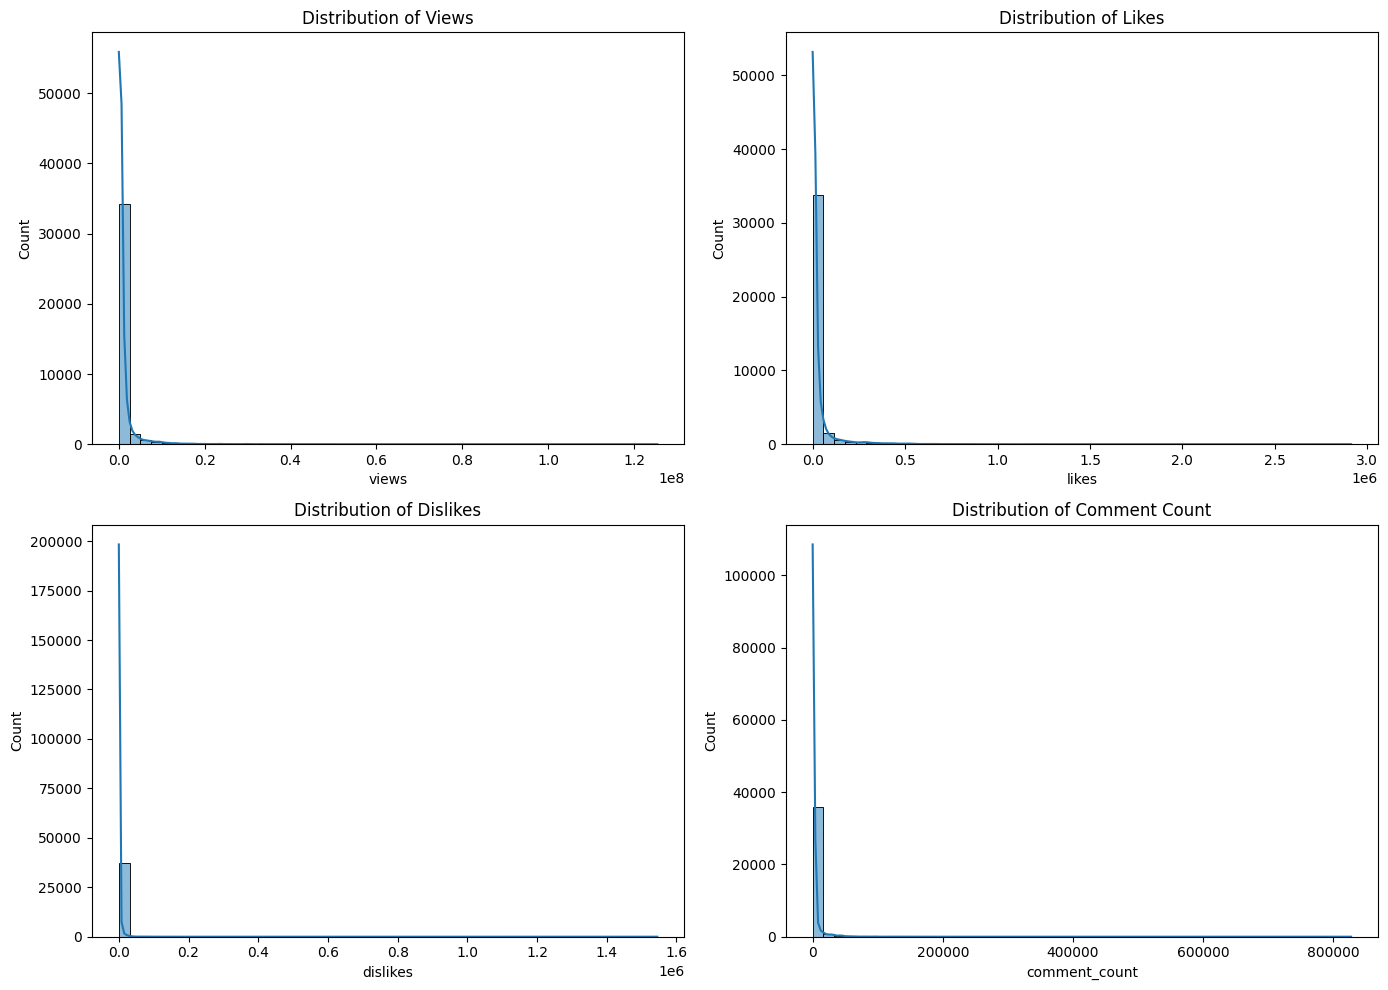

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Views
sns.histplot(df['views'], bins=50, kde=True, ax=axes[0,0])
axes[0,0].set_title('Distribution of Views')

# Likes
sns.histplot(df['likes'], bins=50, kde=True, ax=axes[0,1])
axes[0,1].set_title('Distribution of Likes')

# Dislikes
sns.histplot(df['dislikes'], bins=50, kde=True, ax=axes[1,0])
axes[1,0].set_title('Distribution of Dislikes')

# Comment Count
sns.histplot(df['comment_count'], bins=50, kde=True, ax=axes[1,1])
axes[1,1].set_title('Distribution of Comment Count')

plt.tight_layout()
plt.show()

In [ ]:
df['days_to_trend'].isna().sum()

np.int64(0)

In [ ]:
print(df['trending_date'].dtype)
print(df['publish_date'].dtype)

datetime64[ns]
datetime64[ns]


In [ ]:
df['days_to_trend'].describe()

,days_to_trend
count,37247.000000
mean,2.089215
std,2.067451
min,0.000000
25%,1.000000
50%,2.000000
75%,3.000000
max,221.000000


The data is heavily right-skewed with most values between 0–5 days, but the x-axis stretches to 221 (the max outlier), will make the bars look invisible/flat.

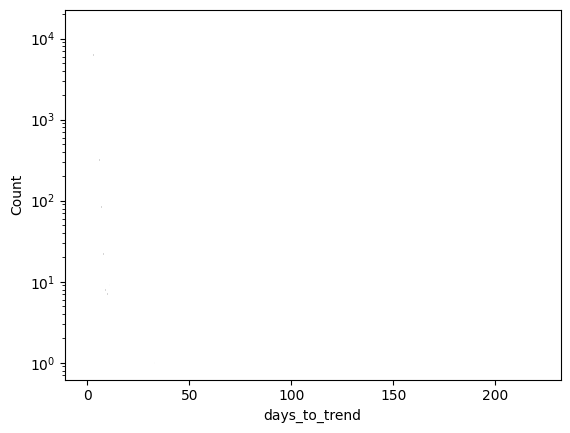

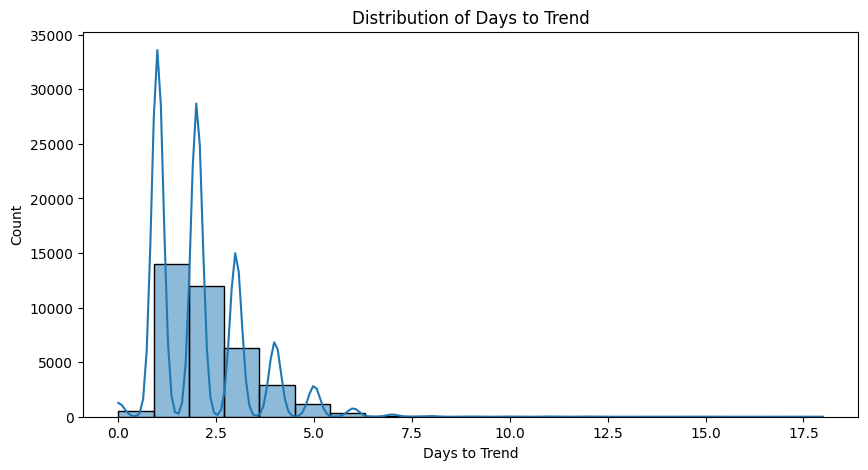

In [ ]:
sns.histplot(df[df['days_to_trend'] <= 20]['days_to_trend'])

# Log scale on y-axis (handles skew well)
sns.histplot(df['days_to_trend'], log_scale=(False, True))

fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(df[df['days_to_trend'] <= 20]['days_to_trend'],
             bins=20, kde=True, ax=ax)
ax.set_xlabel('Days to Trend')
ax.set_ylabel('Count')
ax.set_title('Distribution of Days to Trend')
plt.show()

<Axes: >

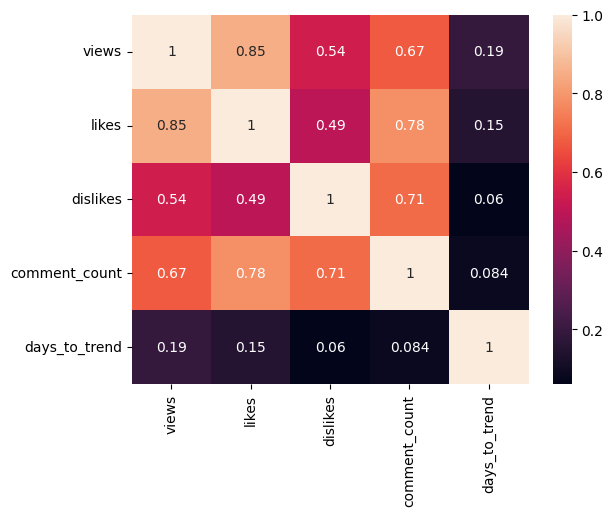

In [ ]:
numeric_cols = [
    'views',
    'likes',
    'dislikes',
    'comment_count',
    'days_to_trend'
]

sns.heatmap(df[numeric_cols].corr(), annot=True)

#**Temporal Analysis**

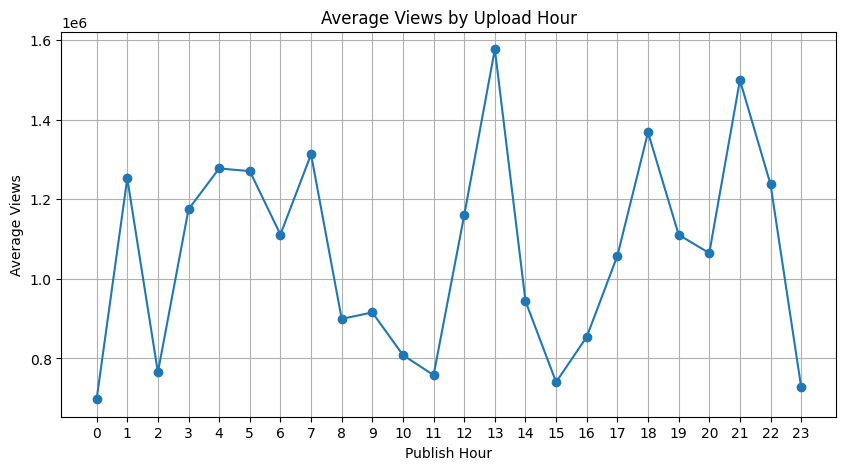

In [ ]:
#Which Upload Hour Performs Best
hourly_views=df.groupby('publish_hour')['views'].mean()
plt.figure(figsize=(10,5))
plt.plot(hourly_views.index, hourly_views.values, marker='o')

plt.xlabel("Publish Hour")
plt.ylabel("Average Views")
plt.title("Average Views by Upload Hour")
plt.xticks(range(24))
plt.grid(True)

plt.show()

Question:What upload time maximizes visibilty?                                                                                                                                                       
Answer: From the plot it is clear that at 13 th
hour and 21st hour shows the possibility of getting maximum views

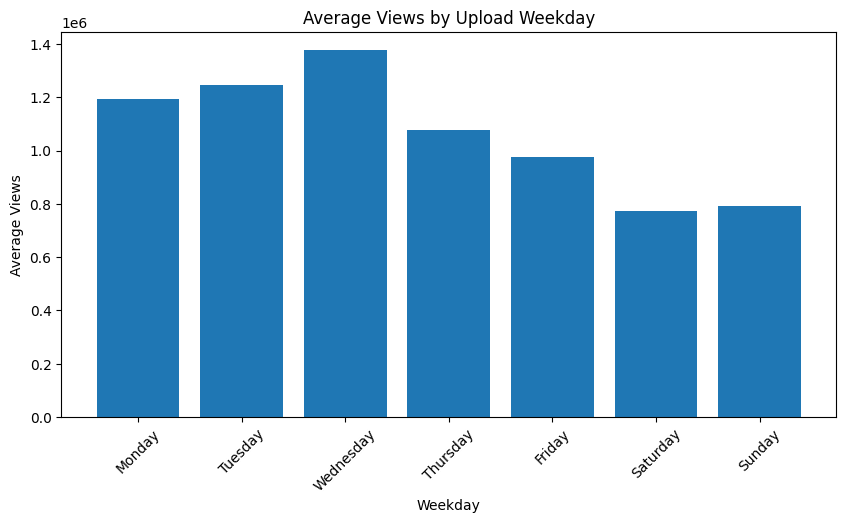

In [ ]:
#Which Day performs best
#A barplot is better for categorcal columns as it not continuos unlike days of hour
weekday_views = df.groupby(
    'publish_weekday'
)['views'].mean()
weekday_views = df.groupby('publish_weekday')['views'].mean()
# Arrange weekdays properly
order = ['Monday', 'Tuesday', 'Wednesday',
         'Thursday', 'Friday', 'Saturday', 'Sunday']

weekday_views = weekday_views.reindex(order)

plt.figure(figsize=(10,5))
plt.bar(weekday_views.index, weekday_views.values)

plt.xlabel("Weekday")
plt.ylabel("Average Views")
plt.title("Average Views by Upload Weekday")

plt.xticks(rotation=45)
plt.show()

Uploading videos on monday,Tuesday and Wednesday give a significant amount of Average views as compared to other days  

###**Category Trend Speed**

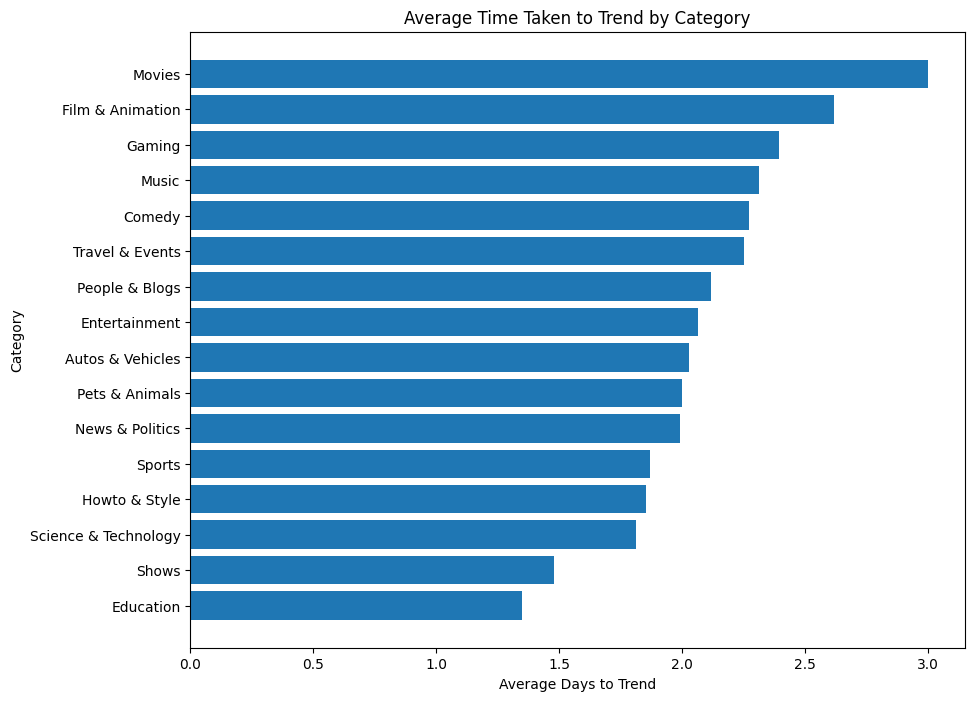

In [ ]:
category_trend_time = df.groupby('category_name')[
    'days_to_trend'
].mean().sort_values()
plt.figure(figsize=(10,8))

plt.barh(
    category_trend_time.index,
    category_trend_time.values
)

plt.xlabel("Average Days to Trend")
plt.ylabel("Category")
plt.title("Average Time Taken to Trend by Category")

plt.show()

Movies and Film and Animation trend more easily as compared to other categories

###**Daily Trending Activity**

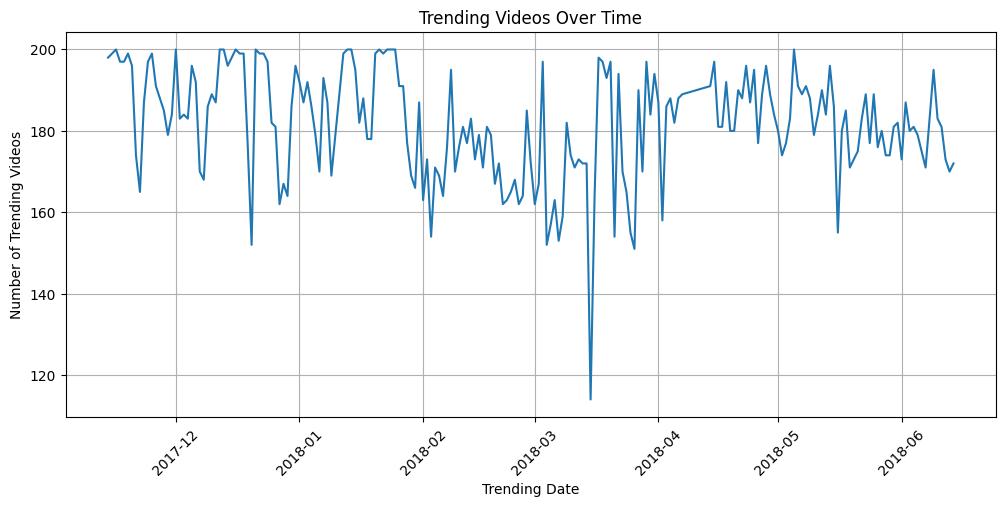

In [ ]:
daily_trends = df.groupby(
    'trending_date'
).size()
plt.figure(figsize=(12,5))

plt.plot(
    daily_trends.index,
    daily_trends.values
)

plt.xlabel("Trending Date")
plt.ylabel("Number of Trending Videos")
plt.title("Trending Videos Over Time")

plt.xticks(rotation=45)
plt.grid(True)

plt.show()

###**Rolling Average Trends**

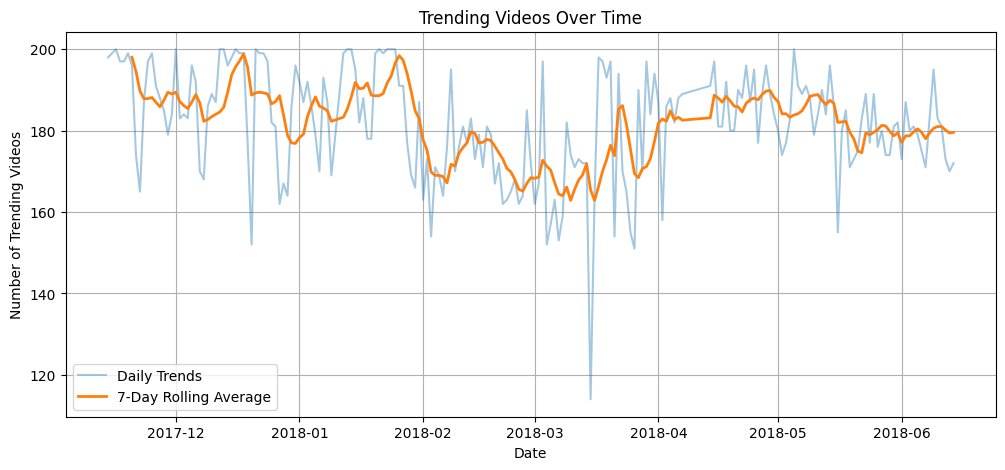

In [ ]:
rolling_views = (
    daily_trends
    .rolling(window=7)
    .mean()
)

plt.figure(figsize=(12,5))

# Original daily trends
plt.plot(
    daily_trends.index,
    daily_trends.values,
    alpha=0.4,
    label='Daily Trends'
)

# 7-day rolling average
plt.plot(
    rolling_views.index,
    rolling_views.values,
    linewidth=2,
    label='7-Day Rolling Average'
)

plt.xlabel("Date")
plt.ylabel("Number of Trending Videos")
plt.title("Trending Videos Over Time")

plt.legend()
plt.grid(True)

plt.show()

#**Statistical Hypothesis Testing**

A. Weekend vs Weekday Hypothesis Testing (T-Test)
Null and Alternative Hypothesis
Null Hypothesis H
0
	​


There is no significant difference between weekend and weekday views.

H
o
	​: μ
weekend
	​
=μ
weekday
	​

Alternative Hypothesis H
1
	​


There is a significant difference between weekend and weekday views.

H
1
	​
: μ
weekend
	!= μ
 weekday
	​


In [ ]:
from scipy.stats import ttest_ind
import numpy as np

# Optional but recommended
df['log_views'] = np.log1p(df['views'])

# Create weekend column
df['is_weekend'] = df['publish_weekday'].isin(
    ['Saturday', 'Sunday']
)

# Separate data
weekend_views = df[
    df['is_weekend'] == True
]['log_views']

weekday_views = df[
    df['is_weekend'] == False
]['log_views']

# Perform t-test
t_stat, p_value = ttest_ind(
    weekend_views,
    weekday_views,
    equal_var=False
)

print("T-statistic:", t_stat)
print("P-value:", p_value)

# Hypothesis testing
alpha = 0.05

print("\nNull Hypothesis (H0):")
print("Weekend and weekday mean views are equal")

print("\nAlternative Hypothesis (H1):")
print("Weekend and weekday mean views are different")

if p_value < alpha:
    print("\nSince p-value <", alpha)
    print("Reject H0")
    print("Conclusion: Upload timing (weekend/weekday) significantly affects views.")
else:
    print("\nSince p-value >=", alpha)
    print("Fail to reject H0")
    print("Conclusion: No statistically significant difference found.")

T-statistic: -10.587215135959445
P-value: 4.058080845380734e-26

Null Hypothesis (H0):
Weekend and weekday mean views are equal

Alternative Hypothesis (H1):
Weekend and weekday mean views are different

Since p-value < 0.05
Reject H0
Conclusion: Upload timing (weekend/weekday) significantly affects views.


B. **ANOVA**

Across Categories
Null Hypothesis Ho
	​


All categories have the same mean views.

Ho
	​
: μ
1
	​=μ
2
	​
=μ
3
	​
=…


Alternative Hypothesis H
1
	​


At least one category has a different mean view count.

H
1
	​
: At least one μ
i  
	​
  differs

In [ ]:
from scipy.stats import f_oneway
import numpy as np

# Optional but recommended
df['log_views'] = np.log1p(df['views'])

# Create category groups
category_groups = [
    group['log_views'].values
    for name, group in df.groupby('category_name')
]

# Perform ANOVA
f_stat, p_value = f_oneway(*category_groups)

print("F-statistic:", f_stat)
print("P-value:", p_value)

alpha = 0.05

print("\nNull Hypothesis (H0):")
print("All categories have equal mean views")

print("\nAlternative Hypothesis (H1):")
print("At least one category has different mean views")

if p_value < alpha:
    print("\nSince p-value <", alpha)
    print("Reject H0")
    print("Conclusion: Category significantly affects video views.")
else:
    print("\nSince p-value >=", alpha)
    print("Fail to reject H0")
    print("Conclusion: No statistically significant category effect found.")

F-statistic: 453.139130954297
P-value: 0.0

Null Hypothesis (H0):
All categories have equal mean views

Alternative Hypothesis (H1):
At least one category has different mean views

Since p-value < 0.05
Reject H0
Conclusion: Category significantly affects video views.


#**Business Insights**


Upload timing plays a significant role in video visibility and audience reach. Certain hours of the day consistently generate higher average view counts, indicating the presence of peak audience activity periods.


Weekday uploads tend to perform better than weekend uploads, suggesting that audience engagement is higher during regular work and study routines compared to weekends.


Categories such as Film & Animation and Movies reach trending status faster than several other categories, indicating that highly entertainment-focused content spreads more rapidly among viewers.


Engagement-related metrics such as likes and comments show a strong association with view counts, implying that audience interaction is an important factor in improving content visibility and recommendation potential.


The distribution of views, likes, and comments is highly skewed, showing that a small proportion of videos capture the majority of audience attention and engagement.


Trending activity varies over time, indicating that audience behavior is dynamic and influenced by temporal factors such as events, seasons, holidays, or platform-level changes.


Statistical hypothesis testing confirms that several observed differences are not due to random variation alone. Upload timing and content categories exhibit statistically significant effects on video performance.


Different content categories display different audience behavior patterns, suggesting that upload strategies and engagement optimization techniques should be tailored according to content type.


Rolling average analysis reveals underlying long-term trends in trending activity while reducing short-term fluctuations, making overall platform engagement patterns easier to observe.


The analysis highlights that strategic scheduling, engagement optimization, and category-aware publishing can significantly improve the probability of achieving higher visibility and trending performance.


#**Conclusion**

The analysis demonstrates that video performance on YouTube is strongly influenced by upload timing, audience engagement, and content category. Temporal patterns reveal that audience activity is not uniform throughout the week or day, making strategic upload scheduling an important factor in maximizing visibility.
Statistical testing further confirms that differences in video performance across categories and upload timings are significant rather than random. Engagement metrics such as likes and comments also emerge as key indicators of audience interest and content reach.
Overall, the study shows that data-driven publishing strategies can improve audience reach, trending potential, and overall content performance.**